# Intro

Name:  

    NURTURE_HALO_RH_sonde

Purpose:  

    Compare the Tropopause heights derived from drop sondes to the tropopause derived from the RH / H20 Mass mixing Ration

Input:

    none at command line

Output:

    plots

Keywords:

    none

Dependencies:

    - numpy
    - Pyephem
    - pandas

Needed Files:

  - HALO hdf5
  - AVAPS drop sonde netcdf

Modification History:

    Written: Samuel LeBlanc, Goose Bay, Labrador, Canada, 2026-02-12
    Modified: 

# Load the required modules and prepare the paths

In [2]:
import matplotlib 
#matplotlib.rc_file('C:\\Users\\sleblan2\\Research\\python_codes\\file.rc')
import matplotlib.pyplot as plt
#%matplotlib widget
import numpy as np
import os
import scipy.io as sio

In [3]:
import map_utils as mu
import matplotlib.colors as colors
from load_utils import mat2py_time, toutc, load_ict
from path_utils import getpath
from scipy.interpolate import interp1d
from datetime import datetime
from matplotlib.cm import get_cmap

In [30]:
import load_utils as lu

In [4]:
import pandas as pd
from tqdm.notebook import tqdm

In [15]:
fp = getpath('NURTURE2026') #,path=r"C:\Users\sleblan2\OneDrive - NASA\NURTURE\flights_2026",make_path=True)
fp_fl = fp+r'20260207_RF10\\'
fp

Return path named:  NURTURE2026 C:\Users\sleblan2\OneDrive - NASA\NURTURE\flights_2026\


'C:\\Users\\sleblan2\\OneDrive - NASA\\NURTURE\\flights_2026\\'

In [16]:
vr = '0'

# load the files

In [21]:
import h5py as hp

In [20]:
import hdf5storage as hs

C:\Users\sleblan2\miniforge3\envs\jupyterlab\Lib\site-packages\hdf5storage\utilities.py:44: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [23]:
halo = hp.File(fp_fl+'NURTURE-HALO_G3_20260207_RA_L1.h5')

In [32]:
halo.keys()

<KeysViewHDF5 ['DataProducts', 'Nav_Data', 'State', 'UserInput', 'time']>

In [34]:
halo['DataProducts'].keys()

<KeysViewHDF5 ['1064_aer_dep', '1064_bsc', '1064_bsc_Sa', '1064_bsc_cloud_screened', '1064_bsr', '1064_bsr_cloud_screened', '1064_dep', '1064_ext', '1064_total_attn_bsc', '532_Sa', '532_aer_dep', '532_bsc', '532_bsc_Sa', '532_bsc_cloud_screened', '532_bsr', '532_bsr_cloud_screened', '532_dep', '532_ext', '532_extinction_from_backscatter', '532_total_attn_bsc', 'Aerosol_ID', 'PWV_bottom_bin_v', 'PWV_clear_v', 'PWV_cloudy_v', 'PWV_top_bin_v', 'RHi_v', 'RHw_v', 'WVD_1064_532', 'cloud_top_height', 'cloud_top_height_935', 'h2o_mmr_v', 'lat', 'lon', 'mask_low', 'range_cell_v', 'z']>

In [38]:
time = halo['time'][:]

In [42]:
z = halo['DataProducts']['z'][:]

In [41]:
lat = halo['Nav_Data']['gps_lat'][:]
lon = halo['Nav_Data']['gps_lon'][:]
alt = halo['Nav_Data']['gps_alt'][:]

In [46]:
len(z),len(alt),len(time)

(831, 1897, 1897)

# Plot the inital curtains

In [73]:
help(plt.colorbar)

Help on function colorbar in module matplotlib.pyplot:

colorbar(
    mappable: 'ScalarMappable | ColorizingArtist | None' = None,
    cax: 'matplotlib.axes.Axes | None' = None,
    ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None,
    **kwargs
) -> 'Colorbar'
    Add a colorbar to a plot.

    Parameters
    ----------
    mappable
        The `matplotlib.cm.ScalarMappable` (i.e., `.AxesImage`,
        `.ContourSet`, etc.) described by this colorbar.  This argument is
        mandatory for the `.Figure.colorbar` method but optional for the
        `.pyplot.colorbar` function, which sets the default to the current
        image.

        Note that one can create a `.ScalarMappable` "on-the-fly" to
        generate colorbars not attached to a previously drawn artist, e.g.
        ::

            fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)

    cax : `~matplotlib.axes.Axes`, optional
        Axes into which the colorbar will be drawn.  If `None`,

In [49]:
halo['DataProducts']['h2o_mmr_v'].shape

(1897, 831)

In [50]:
time.shape

(1897,)

In [51]:
z.shape

(831,)

In [66]:
np.nanmin(halo['DataProducts']['h2o_mmr_v'][:].T),np.nanmax(halo['DataProducts']['h2o_mmr_v'][:].T)

(np.float64(9.090260007138828e-06), np.float64(21.028687582917712))

TypeError: Colorbar.__init__() got an unexpected keyword argument 'max'. Did you mean 'ax'?

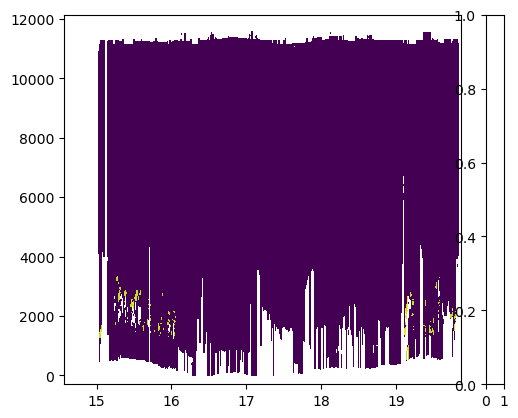

In [72]:
plt.figure()
plt.contourf(time/3600.0,z,halo['DataProducts']['h2o_mmr_v'][:].T,vmin=0.005,vmax=5.0,extend='both')
plt.colorbar(max=5)
plt.show()